# Confirm DuckDB version

In [55]:
import duckdb
print(duckdb.__version__)

1.4.0


## Check API connection to GitHub (should print 200 if all is ok)

In [ ]:
import os
import requests

token = os.environ.get("GITHUB_TOKEN")
if not token:
    raise ValueError("GITHUB_TOKEN environment variable not set. Please set it before running the notebook.")

headers = {"Authorization": f"token {token}"}
url = "https://api.github.com/search/repositories?q=stars:>1000&sort=stars&order=desc&per_page=100&page=1"
response = requests.get(url, headers=headers)
print(response.status_code)
data = response.json()


401


In [57]:
print(data.keys())
print(data['items'][0]['full_name'])


dict_keys(['message', 'documentation_url', 'status'])


KeyError: 'items'

## Save data as a JSON file

In [ ]:
import json

# Save the items (list of repositories) to a file
with open('github_repos.json', 'w') as f:
    json.dump(data['items'], f)


## Use DuckDB to read JSON file

In [ ]:
import duckdb

# Run SQL directly to read JSON into a DuckDB table (requires 'json' extension)
duckdb.sql("INSTALL 'json'; LOAD 'json';")
duckdb.sql("""
    CREATE OR REPLACE TABLE repos AS
    SELECT * FROM read_json_auto('github_repos.json')
""")
rows = duckdb.sql('SELECT full_name, stargazers_count FROM repos ORDER BY stargazers_count DESC LIMIT 10').fetchall()
print(rows)


[('freeCodeCamp/freeCodeCamp', 427798), ('codecrafters-io/build-your-own-x', 420242), ('sindresorhus/awesome', 400507), ('EbookFoundation/free-programming-books', 368337), ('public-apis/public-apis', 365262), ('kamranahmedse/developer-roadmap', 336604), ('jwasham/coding-interview-university', 327985), ('donnemartin/system-design-primer', 319932), ('996icu/996.ICU', 274335), ('vinta/awesome-python', 260091)]


### List the Most Starred Repositories

In [ ]:
results = duckdb.sql("""
    SELECT full_name, stargazers_count
    FROM repos
    ORDER BY stargazers_count DESC
    LIMIT 10
""").fetchall()
for repo in results:
    print(repo)


('freeCodeCamp/freeCodeCamp', 427798)
('codecrafters-io/build-your-own-x', 420242)
('sindresorhus/awesome', 400507)
('EbookFoundation/free-programming-books', 368337)
('public-apis/public-apis', 365262)
('kamranahmedse/developer-roadmap', 336604)
('jwasham/coding-interview-university', 327985)
('donnemartin/system-design-primer', 319932)
('996icu/996.ICU', 274335)
('vinta/awesome-python', 260091)


### Explore Data columns (all columns)

In [ ]:
duckdb.sql("DESCRIBE repos").df()


,column_name,column_type,null,key,default,extra
0,id,BIGINT,YES,None,None,None
1,node_id,VARCHAR,YES,None,None,None
2,name,VARCHAR,YES,None,None,None
3,full_name,VARCHAR,YES,None,None,None
4,private,BOOLEAN,YES,None,None,None
...,...,...,...,...,...,...
76,open_issues,BIGINT,YES,None,None,None
77,watchers,BIGINT,YES,None,None,None
78,default_branch,VARCHAR,YES,None,None,None
79,permissions,"STRUCT(""admin"" BOOLEAN, maintain BOOLEAN, push...",YES,None,None,None


### List top repositories by programming language:

In [ ]:
duckdb.sql("""
    SELECT language, COUNT(*) AS num_repos
    FROM repos
    GROUP BY language
    ORDER BY num_repos DESC
""").df()


,language,num_repos
0,Python,17
1,TypeScript,17
2,JavaScript,14
3,None,13
4,C++,5
5,Go,5
6,Rust,4
7,Java,4
8,HTML,3
9,Shell,3


### Show Top Repositories for a Specific Language

In [ ]:
duckdb.sql("""
    SELECT full_name, stargazers_count, language
    FROM repos
    WHERE language = 'JavaScript'
    ORDER BY stargazers_count DESC
    LIMIT 10
""").df()


,full_name,stargazers_count,language
0,facebook/react,238952,JavaScript
1,trekhleb/javascript-algorithms,193284,JavaScript
2,airbnb/javascript,147409,JavaScript
3,vercel/next.js,134502,JavaScript
4,f/awesome-chatgpt-prompts,134135,JavaScript
5,Chalarangelo/30-seconds-of-code,125290,JavaScript
6,nodejs/node,113257,JavaScript
7,open-webui/open-webui,110144,JavaScript
8,mrdoob/three.js,108600,JavaScript
9,axios/axios,107630,JavaScript


## Data visualization 1

Matplotlib is building the font cache; this may take a moment.


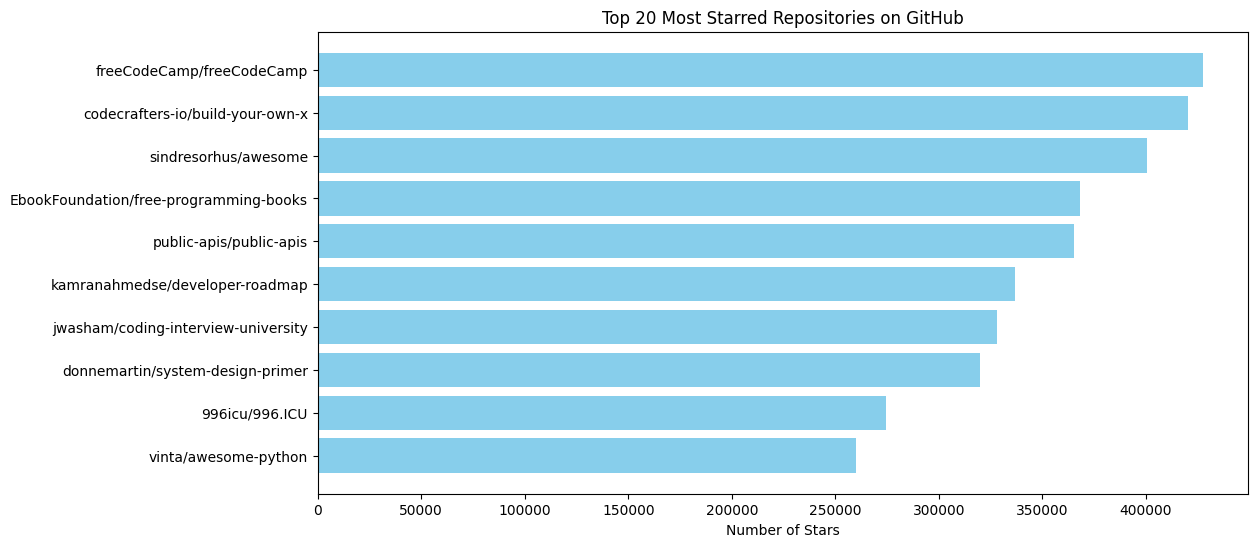

In [ ]:
import matplotlib.pyplot as plt

# Extracting the top 20 repositories and their star counts
top_20_repos = results[:20]
repo_names = [repo[0] for repo in top_20_repos]
star_counts = [repo[1] for repo in top_20_repos]

# Creating the bar chart
plt.figure(figsize=(12, 6))
plt.barh(repo_names, star_counts, color='skyblue')
plt.xlabel('Number of Stars')
plt.title('Top 20 Most Starred Repositories on GitHub')
plt.gca().invert_yaxis()  # Invert y axis to have the most starred on top
plt.show()

## Data visualisation 2

/var/folders/c7/gv30nlgn5y1g9hvscq1pjh2r0000gn/T/ipykernel_70690/1533459764.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


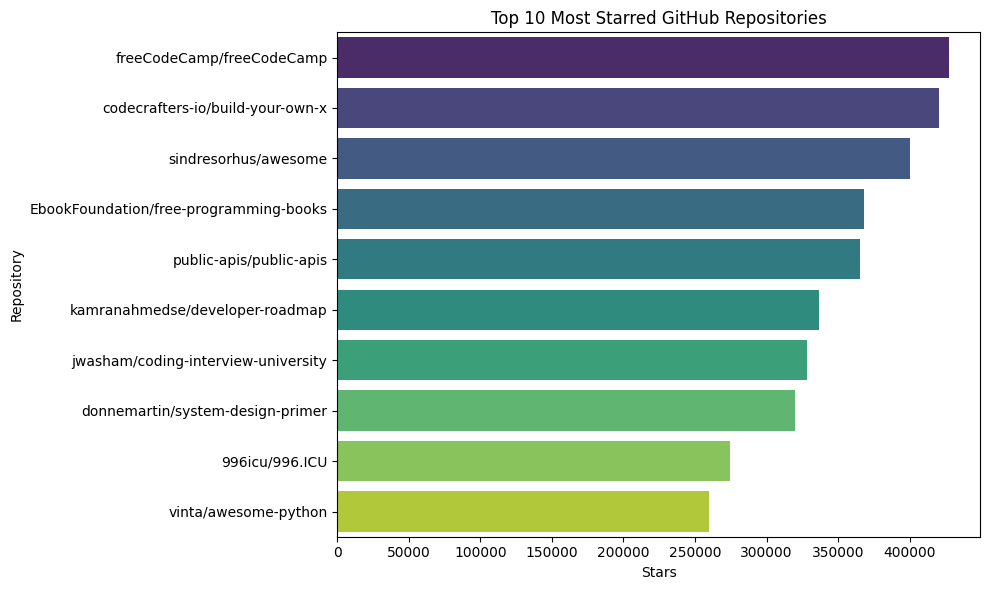

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Query data from DuckDB
top_repos = duckdb.sql("""
    SELECT full_name, stargazers_count
    FROM repos
    ORDER BY stargazers_count DESC
    LIMIT 10
""").df()

plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", n_colors=10)
sns.barplot(
    data=top_repos,
    x="stargazers_count", 
    y="full_name", 
    palette=colors
)
plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 Most Starred GitHub Repositories")
plt.tight_layout()
plt.show()
